<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/lab4_pe_led.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect. LED measurements


0.1.0

# Resume



# LED equation

$$
 h \frac{c}{\lambda} = e V_0
$$

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request

In [2]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


In [3]:
  def find_root(V, I, tolerance=0.99):
    ans = np.nan
    left_edges = np.linspace(np.min(V), np.max(V), 50)
    for left in left_edges:
      mask = (V > left)
      fit = linregress(V[mask], I[mask])
      r2 = fit.rvalue**2
      if r2 > tolerance:
        break
    V0 = - fit.intercept / fit.slope
    return V0

#wl V0
400 2.72
500 2.19
550 2.13
600 1.76
730 1.40



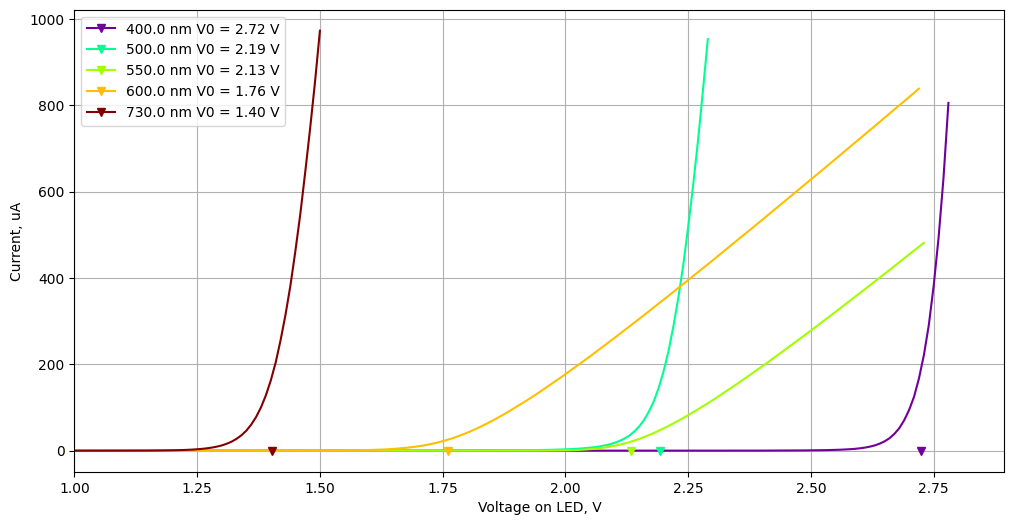

In [54]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/'
MAX_CURRENT = 0.99e-3 #A

name = 'LED_VAC'
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)
fig, ax = plt.subplots(figsize=(12,6))
data = '#wl V0\n'
for wl in np.unique(WL):
  mask = (WL == wl) & (I < MAX_CURRENT )
  color = wavelength_to_color(wl)
  plt.plot(V[mask], I[mask]*1e6, color=color)
  V0 = find_root(V[mask], I[mask])
  plt.plot(V0, 0, color=color, marker='v', label=f'{wl} nm V0 = {V0:.2f} V')
  freq = c/wl *1e9
  data += f'{wl:.0f} {V0:.2f}\n'

plt.legend()
plt.xlabel('Voltage on LED, V')
plt.ylabel('Current, uA')
plt.xlim(left=1)
plt.grid()

print(data)




# Planck

/tmp/ipykernel_1646/2526421720.py:6: RuntimeWarning: divide by zero encountered in divide
  return c * h/ e / energy  * 1e9


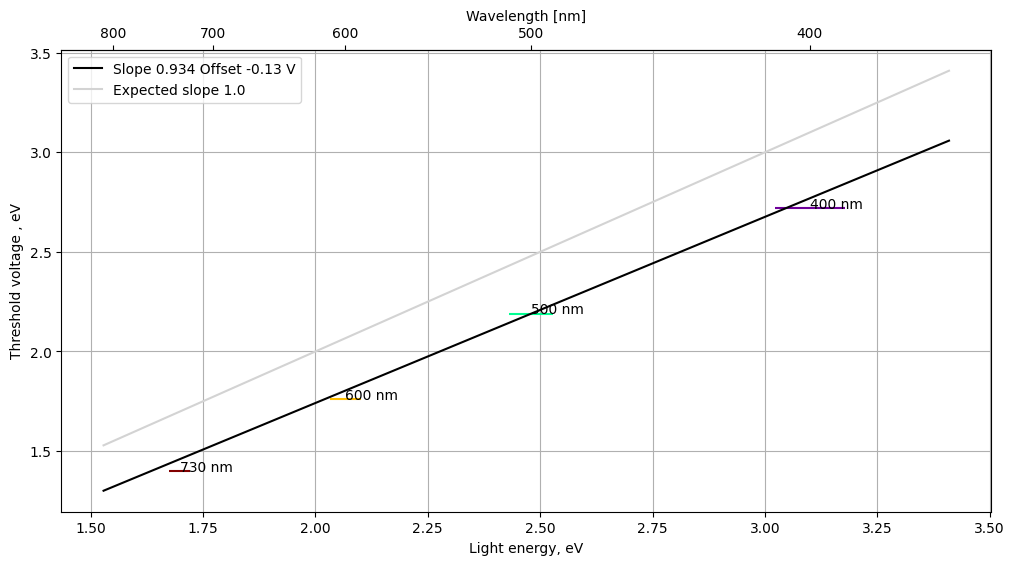

In [57]:

def wl2E(wl):
    return c * h / e / (wl *1e-9)


def E2wl(energy):
    return c * h/ e / energy  * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(wl2E, E2wl))
secax.set_xlabel('Wavelength [nm]')


wl, V0 = np.genfromtxt(data.splitlines()).T



relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
fit = linregress(energy, V0)
slope = fit.slope
offset = fit.intercept




for i in range(len(V0)):
  plt.errorbar( energy[i], V0[i], yerr=0, xerr=energy_err[i], ls='', color=wavelength_to_color(wl[i]*1e9))
  plt.annotate(f'{wl[i]*1e9:.0f} nm', (energy[i], V0[i]))

en_dense = np.linspace(np.min(energy)*0.9, np.max(energy)*1.1)

plt.plot(en_dense, en_dense * slope + offset, color='black',\
         label=rf'Slope {slope:.3f} Offset {offset:.2f} V')
plt.plot(en_dense, en_dense , color='lightgray', label=f'Expected slope 1.0')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light energy, eV')
plt.ylabel(r'Threshold voltage , eV')
plt.legend()
plt.show()

In [56]:
wl

array([4.0e-07, 5.0e-07, 5.5e-07, 6.0e-07, 7.3e-07])

## Discussion

The outlier at bright green nm is explained by article Zollman 2020 "Determining Planck’s constant with LEDs—what could possibly go wrong?" [DOI 10.1088/1361-6552/ab525d](https://iopscience.iop.org/article/10.1088/1361-6552/ab525d)

In [8]:
print(e/slope, h)

6.391584839165571e-34 6.62607015e-34
